<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/IP_lap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt


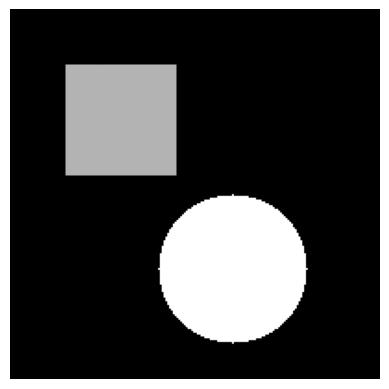

In [2]:
# creat synthetic image

#image size = 200 hight * 200 width
h , w = 200 , 200
# background
img = np.zeros((h, w))

#creat rectanagle
img[30:90, 30:90] = 180

#creat circle
Y, X = np.ogrid[:h, :w]
center = (120, 140)
radius = 40


mask = (X-center[0])**2 + (Y-center[1])**2 <= radius**2
img[mask] = 255

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

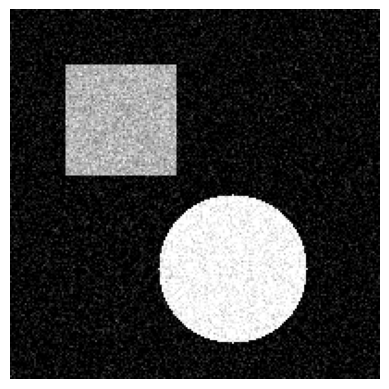

In [ ]:
#generate random noisy
noise = np.random.normal(0, 25, img.shape)

#clip values between 0 & 255
noisy = np.clip(img + noise, 0, 255)

plt.imshow(noisy, cmap='gray')
plt.axis('off')
plt.show()

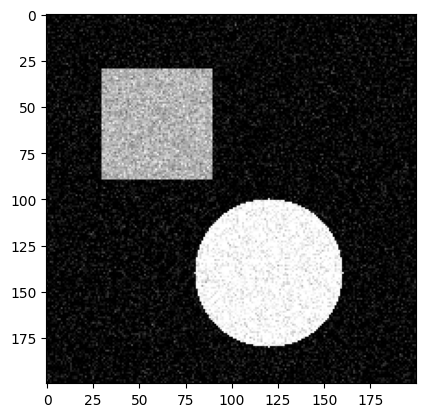

In [ ]:
#enhanced contrast
enhanced = (noisy - noisy.min()) / (noisy.max() - noisy.min()) * 255

plt.imshow(enhanced, cmap='gray')
plt.axis('on')
plt.show()

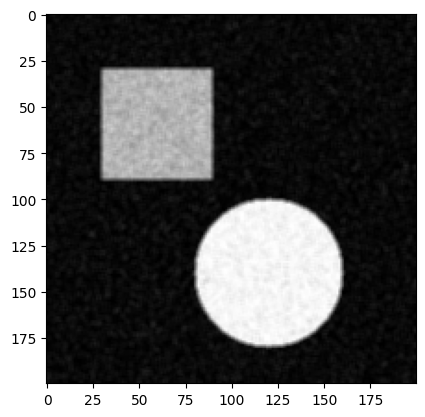

In [ ]:
padded = np.pad(enhanced, 1, mode='edge')
denoised = np.zeros_like(enhanced)

for i in range(h):
    for j in range(w):
        denoised[i, j] = np.mean(padded[i:i+3, j:j+3])

plt.imshow(denoised, cmap='gray')
plt.axis('on')
plt.show()

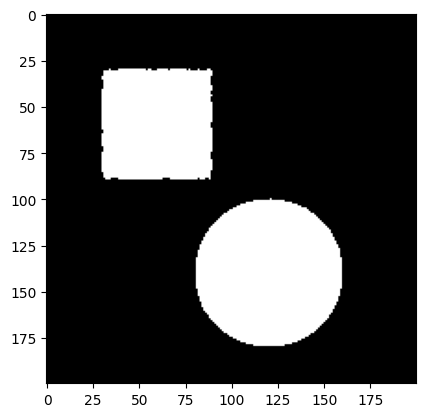

In [ ]:
threshold = 120
segmented = denoised > threshold

plt.imshow(segmented, cmap='gray')
plt.axis('on')
plt.show()

# Reflection question

In [ ]:
#1- Where does image processing end and image analysis begin?
#It ends at segmentation. Analysis begins when we start measuring, counting, or interpreting the objects.

#2- Which steps are low-level processing only?
#Image creation, adding noise, enhancement, denoising, and thresholding — all are image → image operations only.

 #3-Why is digitisation an approximation of reality?
#Because reality is continuous, but digital images use discrete pixels and limited values, so some detail is always lost.